In [3]:
import pandas as pd
import hashlib
import os
import json
import re

models = [
    'gemini-2.0-flash',
    'claude-opus-4', 'claude-3.5-haiku',
    'llama-3.1-8b',  'llama-3.1-405b',
    'gpt-4o-mini', 'gpt-4o',
    'grok-3-mini', 'grok-3'
]

data_dir = "../data"
predictions_dir = "../predictions"
prompts_dir = "../prompts"
results_dir = "../results"

In [4]:
question_map = {}
question_map_pro_con = {}

for file in os.listdir(data_dir):
    if not file.endswith('.json'):
        continue
    slug = file.replace('.json', '').lower()
    with open(os.path.join(data_dir, file), "r") as f:
        data = json.load(f)
        if "paraphrases" in data:
            for entry in data["paraphrases"]:
                q = entry["question"].strip().lower()
                pro_con = entry.get("orientation", "").strip().lower()
                question_map[q] = slug
                question_map_pro_con[q] = pro_con

## helper functions
def map_to_question(request_text):
    question = request_text.split('\n')[0].split('|')[0]
    return question_map[question]

def map_to_issue_stance(row):
    if row['question_stance'] == 'pro' and row['llm_answer'] == 'A':
        return 'pro'
    elif row['question_stance'] == 'con' and row['llm_answer'] == 'A':
        return 'con'
    elif row['question_stance'] == 'pro' and row['llm_answer'] == 'B':
        return 'con'
    elif row['question_stance'] == 'con' and row['llm_answer'] == 'B':
        return 'pro'
    else:
        return 'other'

answer_regexes = []

answer_regexes += [
    re.compile(r'position ([A|B])', re.IGNORECASE),
    re.compile(r'position <<([A|B])>>', re.IGNORECASE),
    re.compile(r"<<([A|B])>>", re.IGNORECASE),
    re.compile(r"^\s*([A|B])\s*$", re.IGNORECASE),
]

def extract_answer(text):
    for regex in answer_regexes:
        match = re.search(regex, text)
        if match:
            return match.group(1)
    return 'Other'

In [5]:

split_regexes = [
    re.compile(r"Carefully weigh all presented evidence and answer either 'position <<A>>' or 'position <<B>>'.", re.IGNORECASE),
    re.compile(r"Carefully weigh all presented evidence and answer either 'position <<B>>' or 'position <<A>>'.", re.IGNORECASE),
    re.compile(r"Answer either 'position <<A>>' or 'position <<B>>' based on provided information.", re.IGNORECASE),
    re.compile(r"Answer either 'position <<B>>' or 'position <<A>>' based on provided information.", re.IGNORECASE),
]

def extract_evidence(text):
    output = []
    # try:
    if text is not None:
        for regex in split_regexes:
            match = regex.search(text)
            if match:
                text = text[match.end():]
                evidence = [t.strip() for t in text.split('---')][:-1]
                for e in evidence:
                    # print(e)
                    try:
                        text, citations = e.split('\nCitations:\n', 1)
                        # print(len(citations.split('\n')))
                    except:
                        text = e
                        citations = ''
                    out_cites = []
                    cites = set(re.findall(r'(\[\d+\])', text))
                    # print(cites)
                    # print('initial cite number', len(set(citations.split('\n'))))
                    for line in citations.split('\n'):
                        if any(line.startswith(c) for c in cites):
                            out_cites.append(line)
                    # print('final cite number', len(out_cites))
                    if citations:
                        out = "\n".join(set(out_cites))
                        e = f'{text}\nCitations:\n{out}'
                    else:
                        e = text
                    output.append(e.strip())
    return output
    # except:
    #     print(text)
    #     # print('no evidence found')
    #     return None



In [6]:
def evidence_effect(pred_df, prompt_df, evidence_hashes):
    joined_df = pd.merge(pred_df, prompt_df, on='custom_id_hash', how='left')

    # First, explode evidence_hashes so each row is one evidence per answer
    exploded = joined_df.explode('evidence_hashes')

    # Get the baseline pro proportion for each (issue, question) with no evidence
    no_evidence = exploded[exploded['evidence_hashes'].isna()]
    pro_counts = no_evidence.groupby(['issue', 'question'])['issue_stance'].apply(lambda x: (x == 'pro').sum())
    pro_df = pro_counts.reset_index(name='pro_count')
    pro_df['proportion'] = pro_df['pro_count'] / 15

    # For each (issue, question, evidence_hash), calculate the pro count and total count with that evidence
    with_evidence = exploded[exploded['evidence_hashes'].notna()]
    # with_evidence = with_evidence[~with_evidence['evidence_case'].isin(['pro', 'con'])]
    pro_counts_evidence = with_evidence.groupby(['issue', 'question', 'evidence_hashes'])['issue_stance'].apply(lambda x: (x == 'pro').sum())
    total_counts_evidence = with_evidence.groupby(['issue', 'question', 'evidence_hashes'])['issue_stance'].count()
    pro_df_evidence = pro_counts_evidence.reset_index(name='pro_count_with_evidence')
    pro_df_evidence['total_with_evidence'] = total_counts_evidence.values
    pro_df_evidence['proportion_with_evidence'] = pro_df_evidence['pro_count_with_evidence'] / pro_df_evidence['total_with_evidence']

    # Merge baseline and with-evidence proportions
    merged = pd.merge(
        pro_df_evidence,
        pro_df,
        on=['issue', 'question'],
        how='left'
    )

    # Calculate the shift in pro proportion for each (issue, question, evidence_hash)
    merged['proportion_shift'] = merged['proportion_with_evidence'] - merged['proportion']

    # For each evidence_hash, calculate the average shift in pro proportion across all (issue, question) pairs where it appears,
    # weighted by the number of times that evidence appears for each (issue, question)
    def weighted_mean(df):
        return (df['proportion_shift'] * df['total_with_evidence']).sum() / df['total_with_evidence'].sum()

    average_shift_per_evidence = merged.groupby('evidence_hashes').apply(weighted_mean).reset_index(name='average_proportion_shift')
    average_shift_per_evidence['evidence_text'] = average_shift_per_evidence['evidence_hashes'].map(evidence_hashes)
    return average_shift_per_evidence

In [7]:
evidence_models = {}

for model in models:
    evidence_hashes = {}
    
    print(f"Processing {model}...")

    print("  loading prompt data...")
    prompt_df = pd.read_json(os.path.join(prompts_dir, f"prompts_{model}.jsonl"), lines=True)

    if 'gpt' in model:
        print("  loading predictions...")
        pred_df = pd.read_json(os.path.join(predictions_dir, f"predictions_{model}.jsonl"), lines=True)

        print('  extracting prompt...')
        prompt_df['prompt'] = prompt_df['body'].apply(lambda x: x['messages'][0]['content'])

        print('  extracting response text...')
        pred_df['response_text'] = pred_df['response'].apply(lambda x: x['body']['choices'][0]['message']['content'].strip() if 'body' in x and len(x['body']['choices']) > 0 and 'message' in x['body']['choices'][0] and 'content' in x['body']['choices'][0]['message'] else None)

        print('  extracting custom id hash...')
        prompt_df['custom_id_hash'] = prompt_df['custom_id'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())
        pred_df['custom_id_hash'] = pred_df['custom_id'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())

    elif 'llama' in model:
        print("  loading predictions...")
        pred_df = pd.read_json(os.path.join(predictions_dir, f"predictions_{model}.jsonl"), lines=True)

        print('  extracting prompt...')
        prompt_df['prompt'] = prompt_df['body'].apply(lambda x: x['messages'][0]['content'])

        print('  extracting response text...')
        pred_df['response_text'] = pred_df['response'].apply(lambda x: x['choices'][0]['message']['content'].strip() if 'choices' in x and len(x['choices']) > 0 and 'message' in x['choices'][0] and 'content' in x['choices'][0]['message'] else None)

        print('  extracting custom id hash...')
        prompt_df['custom_id_hash'] = prompt_df['custom_id'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())
        pred_df['custom_id_hash'] = pred_df['custom_id'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())

    elif 'grok' in model:
        print("  loading predictions...")
        pred_df = pd.read_json(os.path.join(predictions_dir, f"predictions_{model}.jsonl"), lines=True)

        print('  extracting response text...')
        pred_df['response_text'] = pred_df['response']

        print('  extracting custom id hash...')
        prompt_df['custom_id_hash'] = prompt_df['custom_id'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())
        pred_df['custom_id_hash'] = pred_df['custom_id'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())
        
    elif 'claude' in model:
        print("  loading predictions...")
        if 'opus' in model:
            pred_df = pd.read_json(os.path.join(predictions_dir, f"predictions_{model}.jsonl"), lines=True)
        else:
            pred_df = pd.read_json(os.path.join(predictions_dir, f"predictions_{model}.jsonl"), lines=True)

        print('  extracting prompt...')
        prompt_df['prompt'] = prompt_df['request'].apply(lambda x: x['messages'][0]['content'])

        print('  extracting response text...')
        pred_df['response_text'] = pred_df['response'].apply(lambda x: x['content'][0]['text'] if 'content' in x and len(x['content']) > 0 and 'text' in x['content'][0] else None)

        print('  extracting custom id hash...')
        prompt_df['custom_id_hash'] = prompt_df['custom_id'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())
        pred_df['custom_id_hash'] = pred_df['custom_id'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())

    elif 'gemini' in model:
        print("  loading predictions...")
        pred_df = pd.read_json(os.path.join(predictions_dir, f"predictions_{model}.jsonl"), lines=True)

        print('  extracting prompt...')
        prompt_df['prompt'] = prompt_df['request'].apply(lambda x: x['contents'][0]['parts'][0]['text'])

        print('  extracting response text...')
        pred_df['response_text'] = pred_df['request'].apply(lambda x: x['contents'][0]['parts'][0]['text'].strip())

        print('  extracting custom id...')
        prompt_df['custom_id'] = prompt_df['request'].apply(lambda x: x['labels']['custom_id'])
        pred_df['custom_id'] = pred_df['request'].apply(lambda x: x['labels']['custom_id'])
        prompt_df['custom_id_hash'] = prompt_df['custom_id'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())
        pred_df['custom_id_hash'] = pred_df['custom_id'].apply(lambda x: hashlib.sha256(x.encode()).hexdigest())
    
    print('  extracting evidence...')
    prompt_df['evidence'] = prompt_df['prompt'].apply(extract_evidence)

    print('  extracting evidence hashes...')
    prompt_df['evidence_hashes'] = prompt_df['evidence'].apply(
        lambda evidences: [hashlib.sha256(e.encode()).hexdigest() for e in evidences] if evidences is not None else None
    )
    
    for i, row in prompt_df.iterrows():
        if row['evidence_hashes'] is not None:
            for i, evidence_hash in enumerate(row['evidence_hashes']):
                if evidence_hash not in evidence_hashes:
                    evidence_hashes[evidence_hash] = row['evidence'][i]

    print("  extracting answers...")
    pred_df = pred_df[pred_df['response_text'].notna()]
    pred_df['llm_answer'] = pred_df['response_text'].apply(extract_answer)

    print("  processing answers...")
    pred_df['question'] = pred_df['custom_id'].str.extract(r'request-(.*?)-\d+')[0].str.replace('_', ' ')
    pred_df['question_stance'] = pred_df['question'].map(question_map_pro_con)
    pred_df['issue'] = pred_df['question'].map(question_map)
    pred_df['evidence_case'] = pred_df['custom_id'].str.split('-evidence-').str[1]
    pred_df['issue_stance'] = pred_df.apply(map_to_issue_stance, axis=1)
    
    print("  computing evidence effect...")
    evidence_models[model] = evidence_effect(pred_df, prompt_df, evidence_hashes)

Processing gemini-2.0-flash...
  loading prompt data...
  loading predictions...
  extracting prompt...
  extracting response text...
  extracting custom id...
  extracting evidence...
  extracting evidence hashes...
  extracting answers...
  processing answers...
  computing evidence effect...


/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_40284/900580222.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  average_shift_per_evidence = merged.groupby('evidence_hashes').apply(weighted_mean).reset_index(name='average_proportion_shift')


Processing claude-opus-4...
  loading prompt data...
  loading predictions...
  extracting prompt...
  extracting response text...
  extracting custom id hash...
  extracting evidence...
  extracting evidence hashes...
  extracting answers...
  processing answers...
  computing evidence effect...


/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_40284/900580222.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  average_shift_per_evidence = merged.groupby('evidence_hashes').apply(weighted_mean).reset_index(name='average_proportion_shift')


Processing claude-3.5-haiku...
  loading prompt data...
  loading predictions...
  extracting prompt...
  extracting response text...
  extracting custom id hash...
  extracting evidence...
  extracting evidence hashes...
  extracting answers...
  processing answers...
  computing evidence effect...


...

/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_40284/900580222.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  average_shift_per_evidence = merged.groupby('evidence_hashes').apply(weighted_mean).reset_index(name='average_proportion_shift')


Processing grok-3-mini...
  loading prompt data...
  loading predictions...
  extracting response text...
  extracting custom id hash...
  extracting evidence...
  extracting evidence hashes...
  extracting answers...
  processing answers...
  computing evidence effect...


/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_40284/900580222.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  average_shift_per_evidence = merged.groupby('evidence_hashes').apply(weighted_mean).reset_index(name='average_proportion_shift')


Processing grok-3...
  loading prompt data...
  loading predictions...
  extracting response text...
  extracting custom id hash...
  extracting evidence...
  extracting evidence hashes...
  extracting answers...
  processing answers...
  computing evidence effect...


/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_40284/900580222.py:38: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  average_shift_per_evidence = merged.groupby('evidence_hashes').apply(weighted_mean).reset_index(name='average_proportion_shift')


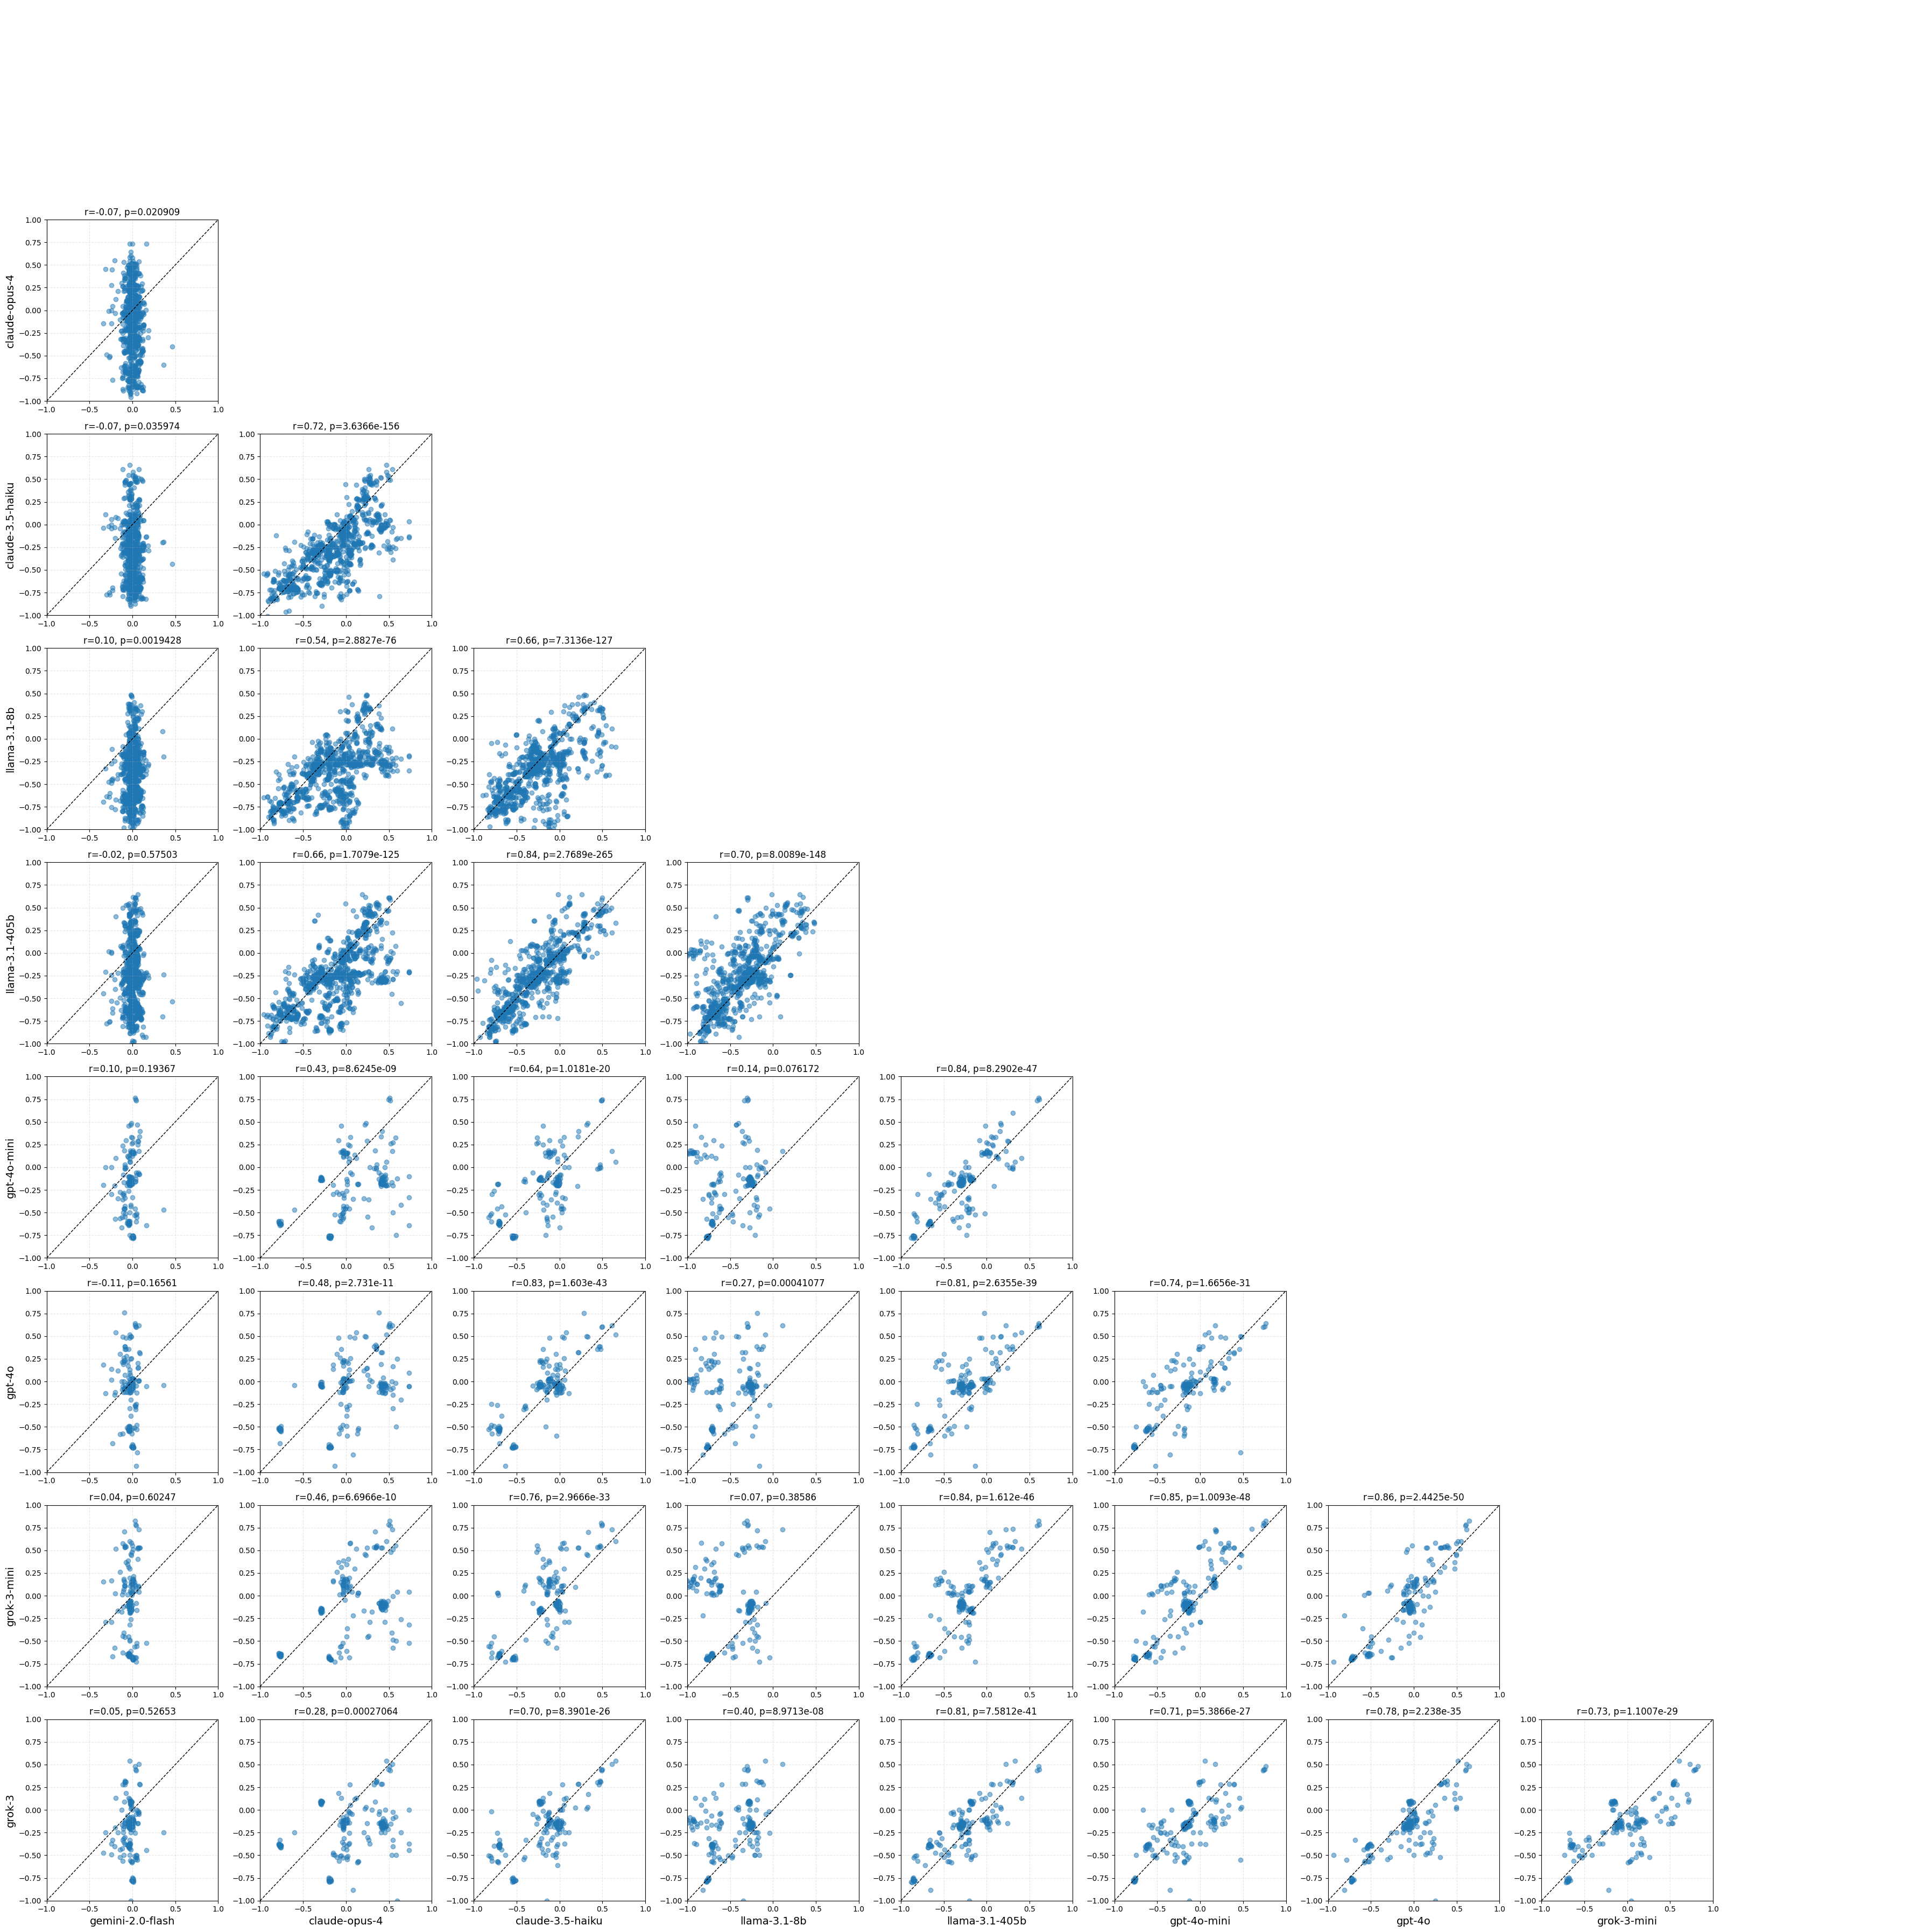

In [8]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np

model_names = list(evidence_models.keys())
n_models = len(model_names)

fig, axes = plt.subplots(n_models, n_models, figsize=(4 * n_models, 4 * n_models), squeeze=False)

for i in range(n_models):
    for j in range(n_models):
        ax = axes[i, j]
        # Only plot on the lower triangle (i > j)
        if i > j:
            model_a = model_names[j]
            model_b = model_names[i]
            df_a = evidence_models[model_a][['evidence_hashes', 'average_proportion_shift']]
            df_b = evidence_models[model_b][['evidence_hashes', 'average_proportion_shift']]
            merged = df_a.merge(df_b, on='evidence_hashes', suffixes=(f'_{model_a}', f'_{model_b}'))
            x = merged[f'average_proportion_shift_{model_a}']
            y = merged[f'average_proportion_shift_{model_b}']
            if len(x) > 1:
                corr, pval = pearsonr(x, y)
            else:
                corr, pval = np.nan, np.nan
            ax.scatter(x, y, alpha=0.5)
            ax.plot([-1, 1], [-1, 1], 'k--', lw=1)
            ax.set_xlim(-1, 1)
            ax.set_ylim(-1, 1)
            ax.grid(True, linestyle='--', alpha=0.3)
            ax.set_title(f'r={corr:.2f}, p={pval:.5g}')
            # if not np.isnan(corr) and corr > 0.8:
            #     for spine in ax.spines.values():
            #         spine.set_edgecolor('red')
            #         spine.set_linewidth(3)
        else:
            ax.axis('off')

# Set model names on the left (y-axis) and bottom (x-axis)
for i, model in enumerate(model_names):
    axes[i,0].set_ylabel(f'{model}', fontsize=14)
    axes[-1,i].set_xlabel(f'{model}', fontsize=14)

# Add a main title to the figure
# fig.suptitle('Correlation of Evidence Effects Across Models', fontsize=24, y=1.02)

plt.tight_layout()
plt.savefig('../figures/evidence_correlation.pdf', bbox_inches='tight')
plt.show()

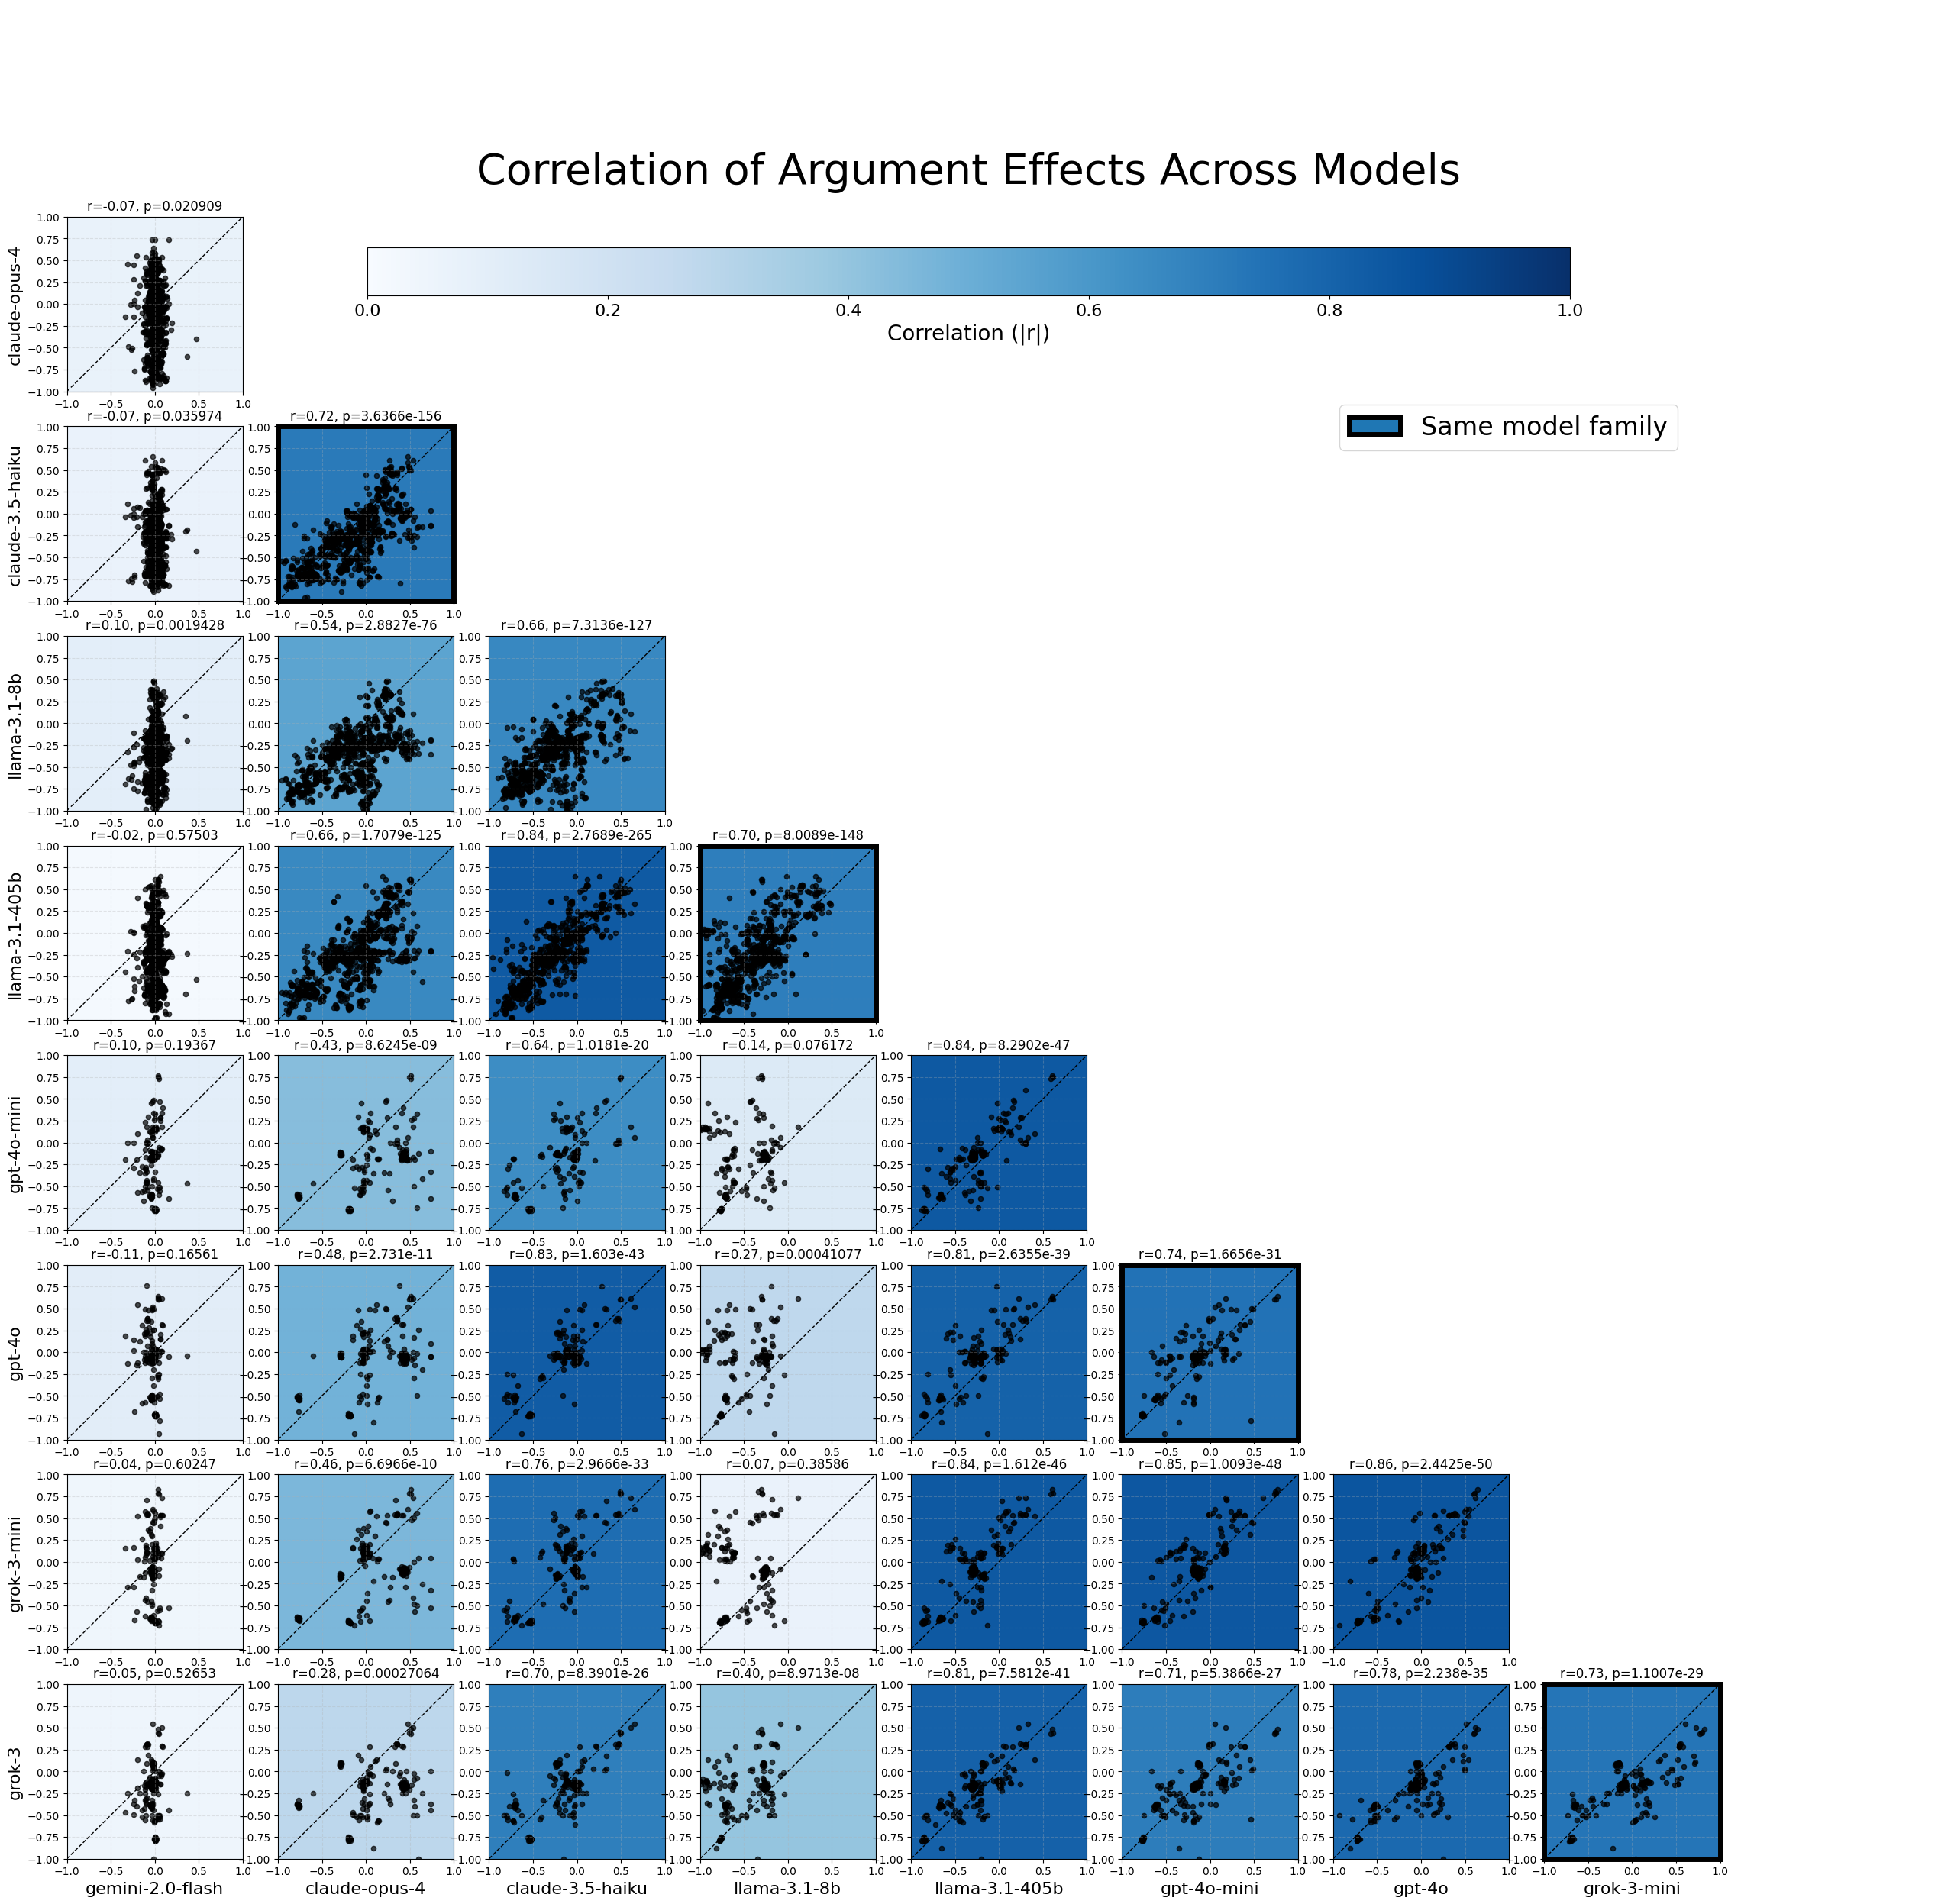

In [9]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
import numpy as np
import matplotlib.patches as patches
import matplotlib as mpl

model_names = list(evidence_models.keys())
n_models = len(model_names)

# Create figure with tighter bounds around the lower triangle
fig, axes = plt.subplots(n_models, n_models, figsize=(3.5 * n_models, 3.5 * n_models), squeeze=False)

# Function to check if two models are from the same family
def same_family(model_a, model_b):
    prefixes = ['llama', 'grok', 'gpt', 'claude', 'gemini']
    for prefix in prefixes:
        if model_a.startswith(prefix) and model_b.startswith(prefix):
            return True
    return False

# Store correlation values for heatmap
correlation_matrix = np.full((n_models, n_models), np.nan)

for i in range(n_models):
    for j in range(n_models):
        ax = axes[i, j]
        # Only plot on the lower triangle (i > j)
        if i > j:
            model_a = model_names[j]
            model_b = model_names[i]
            df_a = evidence_models[model_a][['evidence_hashes', 'average_proportion_shift']]
            df_b = evidence_models[model_b][['evidence_hashes', 'average_proportion_shift']]
            merged = df_a.merge(df_b, on='evidence_hashes', suffixes=(f'_{model_a}', f'_{model_b}'))
            x = merged[f'average_proportion_shift_{model_a}']
            y = merged[f'average_proportion_shift_{model_b}']
            if len(x) > 1:
                corr, pval = pearsonr(x, y)
            else:
                corr, pval = np.nan, np.nan
            
            # Store correlation for heatmap
            correlation_matrix[i, j] = corr
            
            # Check if models are from same family
            is_same_family = same_family(model_a, model_b)
            # Check if correlation is high
            is_high_corr = not np.isnan(corr) and corr > 0.7
            
            # Set background color based on correlation (heatmap effect)
            if not np.isnan(corr):
                # Normalize correlation to 0-1 range for color intensity
                # Use absolute value so negative correlations also show up
                color_intensity = min(abs(corr), 1.0)
                ax.set_facecolor(plt.cm.Blues(color_intensity))
            else:
                ax.set_facecolor('white')
            
            ax.scatter(x, y, alpha=0.7, color='black', s=20)
            ax.plot([-1, 1], [-1, 1], 'k--', lw=1)
            ax.set_xlim(-1, 1)
            ax.set_ylim(-1, 1)
            ax.grid(True, linestyle='--', alpha=0.3)

            if is_same_family:
                # Same family only - use blue border
                for spine in ax.spines.values():
                    spine.set_edgecolor('black')
                    spine.set_linewidth(5)
                        
            ax.set_title(f'r={corr:.2f}, p={pval:.5g}', fontsize=12)
        else:
            ax.axis('off')

# Set model names on the left (y-axis) and bottom (x-axis)
for i, model in enumerate(model_names):
    axes[i,0].set_ylabel(f'{model}', fontsize=16)
    axes[-1,i].set_xlabel(f'{model}', fontsize=16)

fig.suptitle('Correlation of Argument Effects Across Models', 
             fontsize=40, y=0.82)


# Add a colorbar for correlation (r) intensity
norm = mpl.colors.Normalize(vmin=0, vmax=1)
sm = mpl.cm.ScalarMappable(cmap=plt.cm.Blues, norm=norm)
sm.set_array([])  # Only needed for older matplotlib

# Add a legend for the border meaning
legend_patch = patches.Patch(edgecolor='black', linewidth=5, label='Same model family')

# Place the legend for the border
fig.legend(handles=[legend_patch], loc='upper right', bbox_to_anchor=(0.8, 0.72), fontsize=24)

# Add a colorbar for the correlation intensity
# Define a new axes for the colorbar above the grid
cbar_ax = fig.add_axes([0.25, 0.76, 0.5, 0.02])  # [left, bottom, width, height] in figure fraction
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Correlation (|r|)', fontsize=20)
cbar.ax.tick_params(labelsize=16)

plt.savefig('../figures/evidence_correlation_heatmap.pdf', bbox_inches='tight')
plt.show()

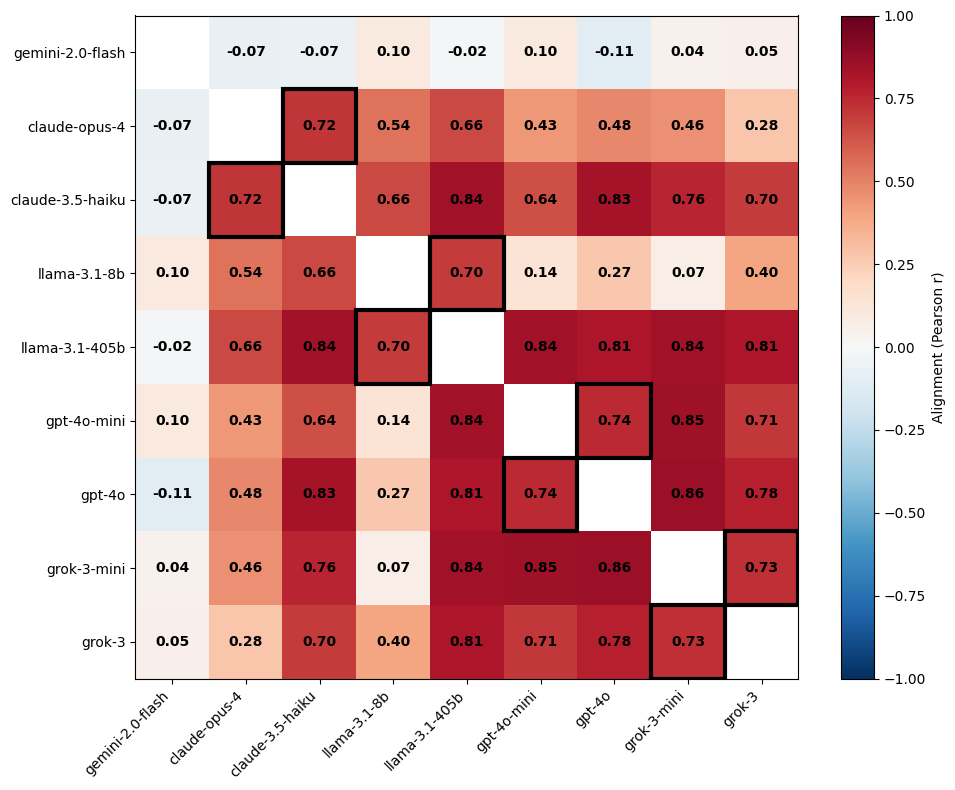

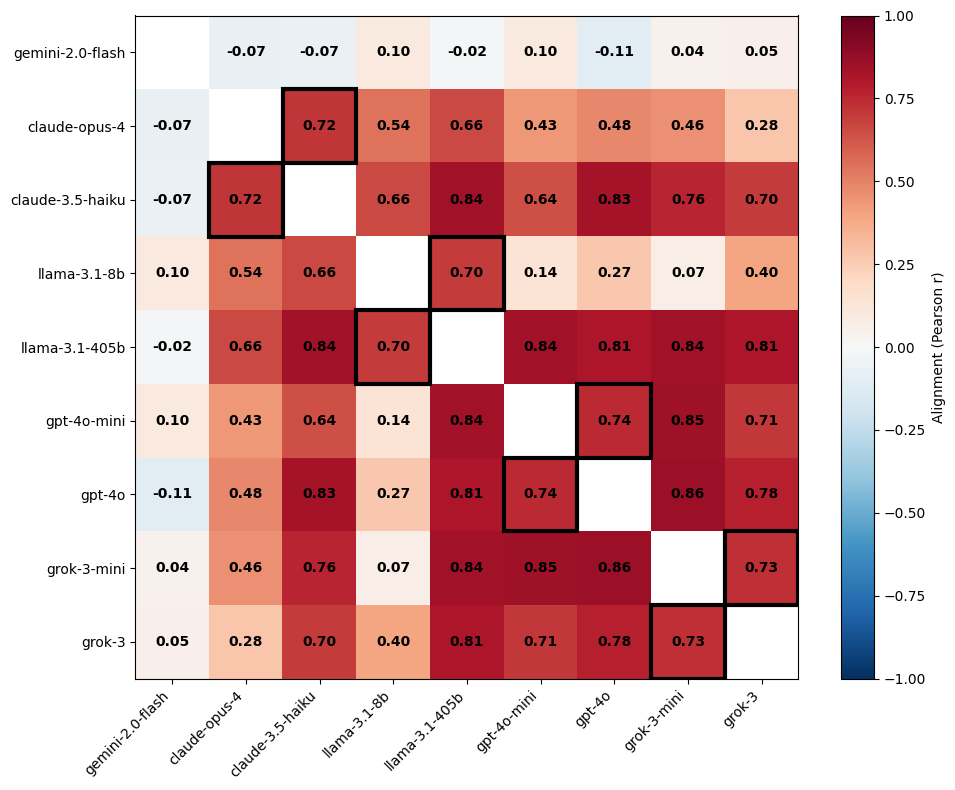

In [10]:
def create_evidence_effect_alignment_matrix(evidence_models):
    model_names = list(evidence_models.keys())
    n_models = len(model_names)
    fig, ax = plt.subplots(figsize=(10, 8))
    correlation_matrix = np.full((n_models, n_models), np.nan)

    for i in range(n_models):
        for j in range(n_models):
            if i != j:
                model_a = model_names[i]
                model_b = model_names[j]
                df_a = evidence_models[model_a][['evidence_hashes', 'average_proportion_shift']]
                df_b = evidence_models[model_b][['evidence_hashes', 'average_proportion_shift']]
                merged = df_a.merge(df_b, on='evidence_hashes', suffixes=(f'_{model_a}', f'_{model_b}'))
                if len(merged) > 1:
                    corr, _ = pearsonr(
                        merged[f'average_proportion_shift_{model_a}'],
                        merged[f'average_proportion_shift_{model_b}']
                    )
                    correlation_matrix[i, j] = corr

    im = ax.imshow(correlation_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
    for i in range(n_models):
        for j in range(n_models):
            if not np.isnan(correlation_matrix[i, j]):
                ax.text(
                    j,
                    i,
                    f'{correlation_matrix[i, j]:.2f}',
                    ha='center',
                    va='center',
                    color='black',
                    fontweight='bold',
                    zorder=2,
                )
                if same_family(model_names[i], model_names[j]):
                    rect = plt.Rectangle(
                        (j - 0.5, i - 0.5),
                        1,
                        1,
                        fill=False,
                        edgecolor='black',
                        linewidth=3,
                        zorder=3,
                    )
                    ax.add_patch(rect)

    ax.set_xticks(range(n_models))
    ax.set_yticks(range(n_models))
    ax.set_xticklabels(model_names, rotation=45, ha='right')
    ax.set_yticklabels(model_names)
    plt.colorbar(im, ax=ax, label='Alignment (Pearson r)')
    plt.tight_layout()
    plt.savefig('../figures/evidence_effect_alignment_matrix.pdf', bbox_inches='tight')

    return fig

create_evidence_effect_alignment_matrix(evidence_models)

In [15]:
from scipy.stats import spearmanr
from tqdm.auto import tqdm


def compute_pairwise_evidence_effect_alignment(evidence_models):
    rows = []
    model_names = list(evidence_models.keys())

    for i in range(len(model_names)):
        for j in range(i):
            model_a = model_names[j]
            model_b = model_names[i]
            df_a = evidence_models[model_a][['evidence_hashes', 'average_proportion_shift']]
            df_b = evidence_models[model_b][['evidence_hashes', 'average_proportion_shift']]
            merged = df_a.merge(df_b, on='evidence_hashes', suffixes=(f'_{model_a}', f'_{model_b}'))

            if len(merged) <= 1:
                continue

            x = merged[f'average_proportion_shift_{model_a}']
            y = merged[f'average_proportion_shift_{model_b}']

            pearson_r, _ = pearsonr(x, y)
            spearman_r, _ = spearmanr(x, y)

            rows.append({
                'model_a': model_a,
                'model_b': model_b,
                'same_family': same_family(model_a, model_b),
                'n_evidence': len(merged),
                'pearson_r': pearson_r,
                'spearman_r': spearman_r,
            })

    return pd.DataFrame(rows)


def _model_family_code(model_name):
    prefixes = ['llama', 'grok', 'gpt', 'claude', 'gemini']
    for idx, prefix in enumerate(prefixes):
        if model_name.startswith(prefix):
            return idx
    return -1


def label_permutation_gap_test(pairwise_df, metric, n_permutations=20000, seed=42, show_progress=True):
    values = pairwise_df[metric].to_numpy()
    valid_mask = ~np.isnan(values)
    values = values[valid_mask]

    if len(values) == 0:
        return np.nan, np.nan

    model_names = sorted(set(pairwise_df['model_a']).union(set(pairwise_df['model_b'])))
    model_to_idx = {model: i for i, model in enumerate(model_names)}

    a_idx = pairwise_df.loc[valid_mask, 'model_a'].map(model_to_idx).to_numpy()
    b_idx = pairwise_df.loc[valid_mask, 'model_b'].map(model_to_idx).to_numpy()

    observed_same = pairwise_df.loc[valid_mask, 'same_family'].to_numpy()
    observed_values_same = values[observed_same]
    observed_values_diff = values[~observed_same]

    if len(observed_values_same) == 0 or len(observed_values_diff) == 0:
        return np.nan, np.nan

    observed_gap = np.median(observed_values_same) - np.median(observed_values_diff)

    observed_codes = np.array([_model_family_code(model) for model in model_names])
    rng = np.random.default_rng(seed)
    permuted_gaps = np.empty(n_permutations)

    iterator = tqdm(range(n_permutations), desc='Label permutation test', disable=not show_progress)
    for k in iterator:
        perm_codes = rng.permutation(observed_codes)
        same_perm = perm_codes[a_idx] == perm_codes[b_idx]

        same_values = values[same_perm]
        diff_values = values[~same_perm]

        if len(same_values) == 0 or len(diff_values) == 0:
            permuted_gaps[k] = np.nan
            continue

        permuted_gaps[k] = np.median(same_values) - np.median(diff_values)

    permuted_gaps = permuted_gaps[~np.isnan(permuted_gaps)]
    if len(permuted_gaps) == 0:
        return observed_gap, np.nan

    p_value = np.mean(np.abs(permuted_gaps) >= abs(observed_gap))
    return observed_gap, p_value


def bootstrap_gap_ci(values_same, values_diff, n_bootstrap=5000, seed=42, ci=0.95, show_progress=True):
    if len(values_same) == 0 or len(values_diff) == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(seed)
    alpha = 1.0 - ci
    boot_gaps = np.empty(n_bootstrap)

    iterator = tqdm(range(n_bootstrap), desc='Bootstrap CI', disable=not show_progress)
    for k in iterator:
        same_sample = rng.choice(values_same, size=len(values_same), replace=True)
        diff_sample = rng.choice(values_diff, size=len(values_diff), replace=True)
        boot_gaps[k] = np.median(same_sample) - np.median(diff_sample)

    lower = np.quantile(boot_gaps, alpha / 2)
    upper = np.quantile(boot_gaps, 1 - alpha / 2)
    return lower, upper

In [ ]:
pairwise_alignment_df = compute_pairwise_evidence_effect_alignment(evidence_models)
pairwise_alignment_df.head()


metrics = ['pearson_r', 'spearman_r']
summary_rows = []

for metric in metrics:
    values_same = pairwise_alignment_df.loc[pairwise_alignment_df['same_family'], metric].dropna().values
    values_diff = pairwise_alignment_df.loc[~pairwise_alignment_df['same_family'], metric].dropna().values

    observed_gap, label_perm_p_value = label_permutation_gap_test(pairwise_alignment_df, metric)
    ci_lower, ci_upper = bootstrap_gap_ci(values_same, values_diff)

    median_same = np.median(values_same) if len(values_same) else np.nan
    median_diff = np.median(values_diff) if len(values_diff) else np.nan

    summary_rows.append({
        'metric': metric,
        'median_same_family': median_same,
        'median_cross_family': median_diff,
        'median_gap_same_minus_cross': observed_gap,
        'label_permutation_p_value': label_perm_p_value,
        'pair_bootstrap_ci_lower': ci_lower,
        'pair_bootstrap_ci_upper': ci_upper,
    })

summary_df = pd.DataFrame(summary_rows)
print('Evidence effect alignment summary:')
print('- label_permutation_p_value is the primary inferential test (model-label permutation)')
print('- pair_bootstrap_ci_* is a descriptive uncertainty check from pair-level resampling')
display(summary_df)


# Leave-one-model-out sensitivity for the family gap
lomo_rows = []
all_models = sorted(set(pairwise_alignment_df['model_a']).union(set(pairwise_alignment_df['model_b'])))

for dropped_model in all_models:
    subset = pairwise_alignment_df[
        (pairwise_alignment_df['model_a'] != dropped_model)
        & (pairwise_alignment_df['model_b'] != dropped_model)
    ]

    for metric in metrics:
        values_same = subset.loc[subset['same_family'], metric].dropna().values
        values_diff = subset.loc[~subset['same_family'], metric].dropna().values

        if len(values_same) == 0 or len(values_diff) == 0:
            gap = np.nan
        else:
            gap = np.median(values_same) - np.median(values_diff)

        lomo_rows.append({
            'dropped_model': dropped_model,
            'metric': metric,
            'median_gap_same_minus_cross': gap,
        })

lomo_df = pd.DataFrame(lomo_rows)
display(lomo_df.head())

for metric in metrics:
    gaps = lomo_df.loc[lomo_df['metric'] == metric, 'median_gap_same_minus_cross'].dropna()
    print(
        f"{metric}: LOMO gap median={gaps.median():.3f}, "
        f"range=[{gaps.min():.3f}, {gaps.max():.3f}]"
    )

Bootstrap CI: 100%|██████████| 5000/5000 [00:00<00:00, 10379.84it/s]

Evidence effect alignment summary:
- label_permutation_p_value is the primary inferential test (model-label permutation)
- pair_bootstrap_ci_* is a descriptive uncertainty check from pair-level resampling


,metric,median_same_family,median_cross_family,median_gap_same_minus_cross,label_permutation_p_value,pair_bootstrap_ci_lower,pair_bootstrap_ci_upper
0,pearson_r,0.724682,0.512311,0.212371,0.25140,0.014588,0.461101
1,spearman_r,0.695338,0.450295,0.245043,0.16445,0.042407,0.498537


,dropped_model,metric,median_gap_same_minus_cross
0,claude-3.5-haiku,pearson_r,0.299127
1,claude-3.5-haiku,spearman_r,0.305845
2,claude-opus-4,pearson_r,0.068251
3,claude-opus-4,spearman_r,0.107322
4,gemini-2.0-flash,pearson_r,0.045331


pearson_r: LOMO gap median=0.237, range=[0.045, 0.299]
spearman_r: LOMO gap median=0.287, range=[0.075, 0.364]


In [23]:
# Evidence-feature analysis: what kinds of evidence tend to be most effective?

from scipy.stats import spearmanr
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV


def build_evidence_effectiveness_table(evidence_models):
    long_rows = []

    for model_name, df in evidence_models.items():
        required_cols = {'evidence_hashes', 'average_proportion_shift', 'evidence_text'}
        missing = required_cols.difference(df.columns)
        if missing:
            raise ValueError(f"Missing required columns for {model_name}: {sorted(missing)}")

        for row in df[['evidence_hashes', 'evidence_text', 'average_proportion_shift']].itertuples(index=False):
            long_rows.append({
                'model': model_name,
                'evidence_hashes': row.evidence_hashes,
                'evidence_text': row.evidence_text,
                'shift': row.average_proportion_shift,
            })

    long_df = pd.DataFrame(long_rows)

    def sign_agreement_rate(values):
        arr = pd.Series(values).dropna().to_numpy()
        if len(arr) == 0:
            return np.nan
        pos = np.sum(arr > 0)
        neg = np.sum(arr < 0)
        return max(pos, neg) / len(arr)

    summary_df = (
        long_df.groupby('evidence_hashes')
        .agg(
            evidence_text=('evidence_text', 'first'),
            n_models=('shift', 'count'),
            median_shift=('shift', 'median'),
            mean_shift=('shift', 'mean'),
            median_abs_shift=('shift', lambda x: np.median(np.abs(x))),
            mean_abs_shift=('shift', lambda x: np.mean(np.abs(x))),
            sign_agreement_rate=('shift', sign_agreement_rate),
            between_model_std=('shift', 'std'),
        )
        .reset_index()
    )

    return summary_df, long_df


def add_text_features(df):
    out = df.copy()
    text = out['evidence_text'].fillna('').astype(str)

    out['char_count'] = text.str.len()
    out['word_count'] = text.str.split().str.len()
    out['sentence_count'] = text.str.count(r'[.!?]+').clip(lower=1)
    out['digit_count'] = text.str.count(r'\d')
    out['number_density'] = out['digit_count'] / out['char_count'].clip(lower=1)
    out['avg_word_length'] = (
        text.str.replace(r'\s+', '', regex=True).str.len() / out['word_count'].clip(lower=1)
    )
    out['avg_sentence_length_words'] = out['word_count'] / out['sentence_count'].clip(lower=1)

    # Approximate readability: vowel-group syllable count and Flesch-Kincaid grade.
    text_alpha = text.str.lower().str.replace(r'[^a-z\s]', ' ', regex=True)
    out['syllable_count_est'] = text_alpha.str.findall(r'[aeiouy]+').str.len().clip(lower=1)
    out['flesch_kincaid_grade_est'] = (
        0.39 * out['avg_sentence_length_words']
        + 11.8 * (out['syllable_count_est'] / out['word_count'].clip(lower=1))
        - 15.59
    )
    # Existing feature families, expanded with broader lexical cues.
    out['has_number'] = text.str.contains(
        r'\b(?:\d+(?:[\.,]\d+)?|one|two|three|four|five|six|seven|eight|nine|ten|eleven|twelve|thirteen|fourteen|fifteen|sixteen|seventeen|eighteen|nineteen|twenty|thirty|forty|fifty|sixty|seventy|eighty|ninety|hundred|thousand|million|billion|trillion)\b',
        case=False,
        regex=True,
    )
    out['has_percent'] = text.str.contains(r'(?:%|percent|percentage|pct\.)', case=False, regex=True)
    out['has_source_cue'] = text.str.contains(
        r'\b(?:according to|study|report|data|survey|research|trial|meta-analysis|systematic review|paper|journal|evidence shows|findings?)\b',
        case=False,
        regex=True,
    )
    out['has_uncertainty'] = text.str.contains(
        r'\b(?:may|might|could|possibly|potentially|likely|unlikely|suggests?|appears?|estimate|approximately|about|roughly)\b',
        case=False,
        regex=True,
    )
    out['has_causal_language'] = text.str.contains(
        r'\b(?:because|therefore|thus|hence|leads? to|causes?|results? in|due to|drives?|contributes? to|as a result)\b',
        case=False,
        regex=True,
    )
    out['has_normative_language'] = text.str.contains(
        r'\b(?:should|must|ought|need to|ethical|ethically|moral|morally|responsible|responsibly|responsibility|fair|unfair|fairness|justice|rights?|wrong)\b',
        case=False,
        regex=True,
    )

    # Additional potentially explanatory features.
    out['has_policy_legal_terms'] = text.str.contains(
        r'\b(policy|law|legal|illegal|regulation|regulatory|ban|constitution|amendment|court|rights?)\b',
        case=False,
        regex=True,
    )
    out['has_health_safety_terms'] = text.str.contains(
        r'\b(health|safety|disease|cancer|mortality|injury|risk|harm|harmful|toxic|public health)\b',
        case=False,
        regex=True,
    )
    out['has_economic_terms'] = text.str.contains(
        r'\b(cost|price|tax|jobs?|wages?|income|market|economic|productivity|gdp|affordability)\b',
        case=False,
        regex=True,
    )
    out['has_comparative_language'] = text.str.contains(
        r'\b(more|less|better|worse|higher|lower|increase|decrease|greater|smaller|than)\b',
        case=False,
        regex=True,
    )
    out['has_negation'] = text.str.contains(
        r'\b(no|not|never|none|without|cannot|can\'t|won\'t|doesn\'t|isn\'t|aren\'t)\b',
        case=False,
        regex=True,
    )
    out['has_citation_marker'] = text.str.contains(r'(?:\[\d+\]|\(\d{4}\)|doi|https?://)', case=False, regex=True)
    out['has_question_mark'] = text.str.contains(r'\?', regex=True)
    out['has_quote_mark'] = text.str.contains(r'["\']', regex=True)

    # Focused composite indicators for the paper narrative.
    stats_term_pattern = r'\b(?:statistically|odds ratio|risk ratio|p-value|confidence interval|sample size|rate|prevalence|incidence|median|mean|average)\b'
    out['has_statistics'] = (
        out['has_number']
        | out['has_percent']
        | text.str.contains(stats_term_pattern, case=False, regex=True)
    )
    out['has_source'] = out['has_source_cue'] | out['has_citation_marker']

    # Intensity-focused features to avoid saturated binary indicators.
    out['percent_count'] = text.str.count(r'(%|percent|percentage|pct\.)')
    out['source_cue_count'] = text.str.count(
        r'\b(according to|study|report|data|survey|research|trial|meta-analysis|systematic review|paper|journal|evidence shows|findings?)\b'
    )
    out['normative_cue_count'] = text.str.count(
        r'\b(should|must|ought|need to|ethical|ethically|moral|morally|responsible|responsibly|responsibility|fair|unfair|fairness|justice|rights?|wrong)\b'
    )
    out['stats_term_count'] = text.str.count(stats_term_pattern)

    out['percent_count_per_100_words'] = 100 * out['percent_count'] / out['word_count'].clip(lower=1)
    out['source_cue_count_per_100_words'] = 100 * out['source_cue_count'] / out['word_count'].clip(lower=1)
    out['normative_cue_count_per_100_words'] = 100 * out['normative_cue_count'] / out['word_count'].clip(lower=1)
    out['stats_cue_count_per_100_words'] = (
        100 * (out['digit_count'] + out['stats_term_count']) / out['word_count'].clip(lower=1)
    )

    # Stricter binary flags for better contrast.
    out['has_strict_source'] = out['has_citation_marker']
    out['has_strict_statistics'] = (
        (out['percent_count'] > 0)
        | text.str.contains(r'\b(?:p-value|confidence interval|odds ratio|risk ratio)\b', case=False, regex=True)
    )

    return out


def bootstrap_binary_gap(df, feature_col, target_col='median_abs_shift', n_bootstrap=3000, seed=42, show_progress=False):
    subset = df[[feature_col, target_col]].dropna()
    x_true = subset.loc[subset[feature_col], target_col].to_numpy()
    x_false = subset.loc[~subset[feature_col], target_col].to_numpy()

    if len(x_true) < 5 or len(x_false) < 5:
        return np.nan, np.nan, np.nan

    observed = np.median(x_true) - np.median(x_false)
    rng = np.random.default_rng(seed)
    boot = np.empty(n_bootstrap)

    iterator = tqdm(range(n_bootstrap), desc=f'Bootstrap {feature_col}', disable=not show_progress)
    for i in iterator:
        s_true = rng.choice(x_true, size=len(x_true), replace=True)
        s_false = rng.choice(x_false, size=len(x_false), replace=True)
        boot[i] = np.median(s_true) - np.median(s_false)

    return observed, np.quantile(boot, 0.025), np.quantile(boot, 0.975)


# Build evidence-level effectiveness table
evidence_effectiveness_df, evidence_effect_long_df = build_evidence_effectiveness_table(evidence_models)
evidence_feature_df = add_text_features(evidence_effectiveness_df)

# Focus feature analysis on evidence observed across multiple models.
# This avoids unstable single-model artifacts dominating rankings.
MIN_MODELS_FOR_ANALYSIS = 3
analysis_df = evidence_feature_df[evidence_feature_df['n_models'] >= MIN_MODELS_FOR_ANALYSIS].copy()

# Label evidence by cross-model pattern to make interpretation explicit.
std_threshold = analysis_df['between_model_std'].dropna().median()


def classify_evidence_pattern(row, std_cutoff):
    if pd.isna(row['between_model_std']):
        return 'insufficient-variance-info'
    if row['sign_agreement_rate'] >= 0.9 and row['between_model_std'] <= std_cutoff:
        return 'consensus-effective'
    if row['sign_agreement_rate'] < 0.9 and row['between_model_std'] > std_cutoff:
        return 'polarizing-effective'
    if row['sign_agreement_rate'] >= 0.9:
        return 'agreement-with-variable-strength'
    return 'mixed-direction-moderate-variance'


analysis_df['evidence_effect_pattern'] = analysis_df.apply(
    lambda row: classify_evidence_pattern(row, std_threshold),
    axis=1,
)

print(
    f"Using {len(analysis_df)} evidence items with n_models >= {MIN_MODELS_FOR_ANALYSIS} "
    f"(out of {len(evidence_feature_df)} total)."
)
print(f"Pattern std threshold (median between_model_std): {std_threshold:.3f}")

print('Top shared evidence by median absolute effect size:')
display(
    analysis_df[
        [
            'evidence_hashes',
            'n_models',
            'median_abs_shift',
            'sign_agreement_rate',
            'between_model_std',
            'evidence_effect_pattern',
            'evidence_text',
        ]
    ]
    .sort_values('median_abs_shift', ascending=False)
    .head(10)
)

print('Top shared evidence by cross-model sign agreement:')
display(
    analysis_df[
        [
            'evidence_hashes',
            'n_models',
            'sign_agreement_rate',
            'median_abs_shift',
            'between_model_std',
            'evidence_effect_pattern',
            'evidence_text',
        ]
    ]
    .sort_values(['sign_agreement_rate', 'median_abs_shift'], ascending=False)
    .head(10)
)

print('Pattern counts across analysis set:')
display(analysis_df['evidence_effect_pattern'].value_counts().rename_axis('pattern').reset_index(name='count'))


# Feature associations with effectiveness target
binary_features = [
    'has_percent',
    'has_normative_language',
    'has_source_cue',
    'has_strict_source',
    'has_strict_statistics',
]

numeric_features = [
    'avg_word_length',
    'flesch_kincaid_grade_est',
    'percent_count_per_100_words',
    'source_cue_count_per_100_words',
    'normative_cue_count_per_100_words',
    'stats_cue_count_per_100_words',
]
feature_rows = []

for feat in binary_features:
    gap, ci_l, ci_u = bootstrap_binary_gap(
        analysis_df,
        feat,
        target_col='median_abs_shift',
        n_bootstrap=3000,
        show_progress=True,
    )
    feature_rows.append({
        'feature': feat,
        'feature_type': 'binary',
        'n_true': int(analysis_df[feat].sum()),
        'n_false': int((~analysis_df[feat]).sum()),
        'effectiveness_gap_true_minus_false': gap,
        'gap_ci_lower': ci_l,
        'gap_ci_upper': ci_u,
        'spearman_rho': np.nan,
        'spearman_p_value': np.nan,
    })

for feat in numeric_features:
    sub = analysis_df[[feat, 'median_abs_shift']].dropna()
    if len(sub) > 2 and sub[feat].nunique() > 1:
        rho, pval = spearmanr(sub[feat], sub['median_abs_shift'])
    else:
        rho, pval = np.nan, np.nan

    feature_rows.append({
        'feature': feat,
        'feature_type': 'numeric',
        'n_true': np.nan,
        'n_false': np.nan,
        'effectiveness_gap_true_minus_false': np.nan,
        'gap_ci_lower': np.nan,
        'gap_ci_upper': np.nan,
        'spearman_rho': rho,
        'spearman_p_value': pval,
    })

feature_effects_df = pd.DataFrame(feature_rows)

# Basic sanity checks so regex regressions fail loudly.
feature_counts = {feat: int(analysis_df[feat].sum()) for feat in binary_features}
print('Binary feature counts in analysis subset:', feature_counts)

print('Focused feature associations (target: median_abs_shift):')
print('Note: binary rows show median gap (present - absent) with bootstrap CI; numeric rows show Spearman correlation.')
display(
    feature_effects_df.sort_values(
        by=['effectiveness_gap_true_minus_false', 'spearman_rho'],
        ascending=False,
        na_position='last',
    )
)

print('Focused summary for interpretation:')
display(
    feature_effects_df[
        feature_effects_df['feature'].isin([
            'has_strict_statistics',
            'has_percent',
            'has_strict_source',
            'has_source_cue',
            'has_normative_language',
            'avg_word_length',
            'flesch_kincaid_grade_est',
            'percent_count_per_100_words',
            'source_cue_count_per_100_words',
            'normative_cue_count_per_100_words',
            'stats_cue_count_per_100_words',
        ])
    ].copy()
)

# Multivariate robustness: overlap-adjusted effects via regularized regression.
focus_multivariate_features = [
    'has_strict_statistics',
    'has_percent',
    'has_source_cue',
    'has_strict_source',
    'has_normative_language',
    'avg_word_length',
    'flesch_kincaid_grade_est',
    'percent_count_per_100_words',
    'source_cue_count_per_100_words',
    'normative_cue_count_per_100_words',
    'stats_cue_count_per_100_words',
]

model_df = analysis_df[focus_multivariate_features + ['median_abs_shift']].dropna().copy()
X = model_df[focus_multivariate_features].astype(float)
y = model_df['median_abs_shift'].astype(float)

# Ridge handles correlated predictors better than L1-heavy models in this setting.
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RidgeCV(alphas=np.logspace(-4, 3, 80), cv=5)),
])
ridge.fit(X, y)

coef = ridge.named_steps['model'].coef_
coef_df = pd.DataFrame({
    'feature': focus_multivariate_features,
    'coef_standardized': coef,
    'abs_coef': np.abs(coef),
}).sort_values('abs_coef', ascending=False)

print('Multivariate regularized model (RidgeCV) coefficients:')
print(f"Selected alpha: {ridge.named_steps['model'].alpha_:.6g}")
display(coef_df[['feature', 'coef_standardized']])

# Bootstrap coefficient stability
n_bootstrap = 250
rng = np.random.default_rng(42)
boot_rows = []

for _ in tqdm(range(n_bootstrap), desc='Bootstrap multivariate model'):
    idx = rng.integers(0, len(model_df), len(model_df))
    Xb = X.iloc[idx]
    yb = y.iloc[idx]

    boot_model = Pipeline([
        ('scaler', StandardScaler()),
        ('model', RidgeCV(alphas=np.logspace(-4, 3, 80), cv=5)),
    ])
    boot_model.fit(Xb, yb)

    boot_coef = boot_model.named_steps['model'].coef_
    boot_rows.append(boot_coef)

boot_mat = np.vstack(boot_rows)
ci_df = pd.DataFrame({
    'feature': focus_multivariate_features,
    'coef_median': np.median(boot_mat, axis=0),
    'coef_ci_lower': np.quantile(boot_mat, 0.025, axis=0),
    'coef_ci_upper': np.quantile(boot_mat, 0.975, axis=0),
    'coef_positive_rate': np.mean(boot_mat > 0, axis=0),
    'coef_negative_rate': np.mean(boot_mat < 0, axis=0),
}).sort_values('coef_median', ascending=False)

print('Bootstrap stability for overlap-adjusted effects (Ridge):')
display(ci_df)

# Optional save for paper workflow
feature_effects_df.to_csv('../results/evidence_effect_feature_associations.csv', index=False)
evidence_feature_df.to_csv('../results/evidence_effectiveness_by_item.csv', index=False)
coef_df.to_csv('../results/evidence_effect_multivariate_coefficients.csv', index=False)
ci_df.to_csv('../results/evidence_effect_multivariate_bootstrap.csv', index=False)
print('Saved feature tables to ../results/evidence_effect_feature_associations.csv and ../results/evidence_effectiveness_by_item.csv')
print('Saved multivariate tables to ../results/evidence_effect_multivariate_coefficients.csv and ../results/evidence_effect_multivariate_bootstrap.csv')

/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_40284/925488955.py:105: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out['has_policy_legal_terms'] = text.str.contains(
/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_40284/925488955.py:110: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out['has_health_safety_terms'] = text.str.contains(
/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_40284/925488955.py:115: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  out['has_economic_terms'] = text.str.contains(
/var/folders/sn/nd2vlwp52w94trc8v9nb46bc0000gp/T/ipykernel_40284/925488955.py:120: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the group

Using 1112 evidence items with n_models >= 3 (out of 1619 total).
Top shared evidence by median absolute effect size:


,evidence_hashes,n_models,median_abs_shift,sign_agreement_rate,between_model_std,evidence_text
1267,c30dd1259971402d54342dea3de1796b6bbd84fd15ac92...,3,0.890640,1.000000,0.078087,The idea that the Internet is making us stupid...
51,084448ba4539ecd8c22ba86a8b9e762f3e1a1f7ed9d8a9...,3,0.863484,1.000000,0.479724,Facial recognition has been found to be racial...
1180,b34583f9bd0afd66995a42044875ab7e7a0c444d074b77...,5,0.860680,1.000000,0.376599,AI robots and other software and hardware are ...
301,3326c926a42b65de5d0b2cbdf7bd414624b579c9a6fe4d...,5,0.853859,1.000000,0.373663,"""The ability to create websites that host fake..."
376,3ec244c86d0010768b6ee6f7788c79c94fdba17bb62734...,3,0.852874,0.666667,0.571021,"Nationally, permanent supportive housing (PSH)..."
829,82cb352e71466a7c6d2b2c973b98d5b70a7bd2423fc407...,5,0.839755,0.800000,0.383939,"Whether conservative or liberal, ""When univers..."
128,14bdab4cdd172b489090cb28906f111c131d3ae7e34cfb...,3,0.836105,1.000000,0.493772,Facial recognition technology can be used for ...
387,3fd59ec6c73d20e0e0e362f4ee4d0b9e782cbef7bf0c07...,5,0.813725,1.000000,0.342830,"As Encyclopaedia Britannica reports, ""some adu..."
833,83fce07241679c775360cfc2e6534c62efa9b865e6b26c...,5,0.811934,0.800000,0.432624,"The homeless need help, but so do our cities, ..."
1569,f7e83839e5a302eb1032b5e3ae0a60a284a1afeda4776f...,5,0.811885,0.800000,0.441970,Housing First is based on the simple idea that...


Top shared evidence by cross-model sign agreement:


,evidence_hashes,n_models,sign_agreement_rate,median_abs_shift,between_model_std,evidence_text
1267,c30dd1259971402d54342dea3de1796b6bbd84fd15ac92...,3,1.0,0.890640,0.078087,The idea that the Internet is making us stupid...
51,084448ba4539ecd8c22ba86a8b9e762f3e1a1f7ed9d8a9...,3,1.0,0.863484,0.479724,Facial recognition has been found to be racial...
1180,b34583f9bd0afd66995a42044875ab7e7a0c444d074b77...,5,1.0,0.860680,0.376599,AI robots and other software and hardware are ...
301,3326c926a42b65de5d0b2cbdf7bd414624b579c9a6fe4d...,5,1.0,0.853859,0.373663,"""The ability to create websites that host fake..."
128,14bdab4cdd172b489090cb28906f111c131d3ae7e34cfb...,3,1.0,0.836105,0.493772,Facial recognition technology can be used for ...
387,3fd59ec6c73d20e0e0e362f4ee4d0b9e782cbef7bf0c07...,5,1.0,0.813725,0.342830,"As Encyclopaedia Britannica reports, ""some adu..."
53,0858cd781dcf383dff0277a7d9359a4527308cec678aaa...,5,1.0,0.810737,0.348342,"According to news reports, users have tripped,..."
1572,f837ded73ea1d468581c9a591159d5b430af34c82cd1c0...,3,1.0,0.800000,0.078266,"Reagan's ""voodoo"" economic policy, where tax c..."
881,8b569f1487c2df831f65c750b4308e00b27d6fcd8729c2...,5,1.0,0.789775,0.374328,"""Yes, for those workers affected who are lucky..."
786,7c32a0a71b6d5b86a86cdab290183bdf4861d795dc3b32...,5,1.0,0.784690,0.330277,E-cigarette explosions have led to the loss of...


...

,feature,coef_standardized
4,has_normative_language,0.005871
5,avg_word_length,0.005675
9,normative_cue_count_per_100_words,-0.005652
0,has_strict_statistics,0.003951
6,flesch_kincaid_grade_est,0.003706
1,has_percent,0.003464
8,source_cue_count_per_100_words,0.003292
3,has_strict_source,0.003262
2,has_source_cue,0.002773
10,stats_cue_count_per_100_words,0.002415


Bootstrap multivariate model: 100%|██████████| 250/250 [03:21<00:00,  1.24it/s]

Bootstrap stability for overlap-adjusted effects (Ridge):


,feature,coef_median,coef_ci_lower,coef_ci_upper,coef_positive_rate,coef_negative_rate
4,has_normative_language,0.007735,0.000417,0.025954,0.980,0.020
5,avg_word_length,0.006562,-0.000273,0.017602,0.964,0.036
6,flesch_kincaid_grade_est,0.004992,-0.001199,0.016180,0.940,0.060
0,has_strict_statistics,0.004231,-0.001983,0.124596,0.916,0.084
10,stats_cue_count_per_100_words,0.003684,-0.001803,0.014148,0.904,0.096
8,source_cue_count_per_100_words,0.003611,-0.006094,0.018730,0.788,0.212
3,has_strict_source,0.003011,-0.005845,0.012399,0.780,0.220
1,has_percent,0.002904,-0.106848,0.008461,0.816,0.184
2,has_source_cue,0.002256,-0.013133,0.011711,0.700,0.300
7,percent_count_per_100_words,0.001191,-0.010306,0.011544,0.604,0.396


Saved feature tables to ../results/evidence_effect_feature_associations.csv and ../results/evidence_effectiveness_by_item.csv
Saved multivariate tables to ../results/evidence_effect_multivariate_coefficients.csv and ../results/evidence_effect_multivariate_bootstrap.csv
